# The note that may say not yet

**Week 1, Thursday. Chapter 5 of 6.** By the end of this notebook you can turn four chapters of
numbers into one page Meera reads in two minutes: claim, evidence with its base, the caveat that
would change the claim, and the action with its cost, with "not yet" where the evidence says so.

> **The client asks.** "One page, two minutes. If the honest answer is 'we do not know yet', say so
> and tell me what would tell us."
>
> Meera Raghavan, CEO, Kalpa Retail

**The metric at stake.** Every number chapters 1 to 4 produced, each now carried with its base.
**Who asks and what rides on it.** Meera, before Monday's growth review, where Marketing will
defend its campaign against the note: a line that loses its base sends money the wrong way, and a
line that hedges everything gives her nothing to decide. **Who else faces it.** Amazon banned slide
presentations from its meetings and replaced them with six-page narrative memos read in silence at
the start of each meeting, which Jeff Bezos described in his 2017 letter to shareholders. A
narrative forces the writer to connect each claim to its evidence, which is this chapter's job on
one page.

Chapters 1 to 4 each left a number. This chapter adds no statistics: it gathers the numbers into
one dictionary, `NUMBERS`, and writes from it.

**Setup.** The whole toolkit, and the day's numbers recomputed into `NUMBERS` from the same helpers
and the same seeds, so every figure in the note traces to a chapter.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import time

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)                  # the same shuffles on every laptop
    pool = q1 + q2                     # all the cards, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)           # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """The share of chance-only worlds whose gap is at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """Redraw each quarter's members with replacement, many times, and keep each gap."""
    random.seed(seed)
    return [mean([random.choice(q1) for _ in q1]) - mean([random.choice(q2) for _ in q2])
            for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")


def spend(rows):
    """August revenue per customer across a list of exposure rows."""
    return mean([int(r["august_revenue"]) for r in rows])


def group(flag, segment=None):
    """The exposure rows for one group, exposed "yes" or "no", optionally inside one segment."""
    return [r for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment)]

NUMBERS = {}
plus_q1, plus_q2 = member_totals("Retail-Plus", "Q1"), member_totals("Retail-Plus", "Q2")
real = mean(plus_q1) - mean(plus_q2)
NUMBERS["share"] = share_at_least(shuffle_gaps(plus_q1, plus_q2, 5000, seed=2026), real)
NUMBERS["fall"] = round(real * len(plus_q1))
NUMBERS["company"] = sum(delivered(s, "Q2") for s in SEGMENTS)
NUMBERS["tier_q1"] = delivered("Retail-Plus", "Q1")
NUMBERS["offer"] = 500 * len(plus_q1)
student_n = sum(1 for o in ORDERS if o["segment"] == "Student")
flips = flip_rises(student_n, 5000, seed=2026)
NUMBERS["student_rise"] = round(100 * orders_in("Student", "Q2") / orders_in("Student", "Q1")) - 100
NUMBERS["student_chance"] = sum(1 for r in flips if r >= 0.4 - 1e-9) / len(flips)
NUMBERS["blend"] = spend(group("yes")) / spend(group("no")) - 1
NUMBERS["within"] = spend(group("yes", "Retail-Plus")) / spend(group("no", "Retail-Plus")) - 1

print(len(NUMBERS), "numbers gathered from chapters 1 to 4")

9 numbers gathered from chapters 1 to 4


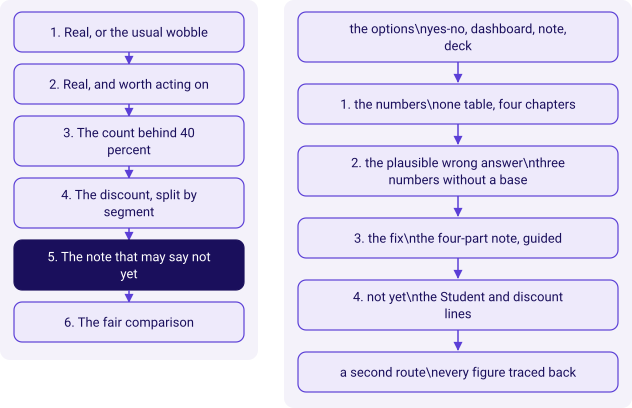

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=4, show=False),
    kit.vflow(['the options\\nyes-no, dashboard, note, deck', '1. the numbers\\none table, four chapters', '2. the plausible wrong answer\\nthree numbers without a base', '3. the fix\\nthe four-part note, guided', '4. not yet\\nthe Student and discount lines', 'a second route\\nevery figure traced back'], show=False),
)

## The options

Four ways a team could answer Meera in writing.

| Option | What it is | What it risks |
|---|---|---|
| A. A yes or no per question | Three words she asked for | Every caveat, and the "not yet" she explicitly allowed |
| B. The dashboard | Every number the chapters produced, in one table | Two minutes spent reading, and no decision on the page |
| C. The four-part note | Claim, evidence with its base, caveat, action with its cost, per question | The discipline to keep it under 200 words |
| D. A slide deck | Ten slides for Monday | A meeting to present it; the logic lives in the talk, never on the page |

Option,"Words, about",Bases carried,What it loses
A. Yes or no,13,none,every caveat
B. Dashboard,58,all of them,the decision
C. Four-part note,200,each claim's,only length
D. Slide deck,250,"on the slides, if drawn",a meeting to present


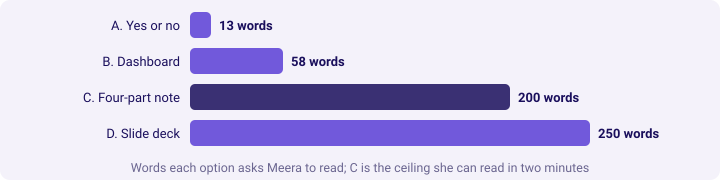

In [3]:
option_a = "Retail-Plus: yes, it is down. Student: yes, move budget. Discount: yes, it worked."
option_b = " ".join(f"{k} {v}" for k, v in NUMBERS.items()) + " " + " ".join(["number"] * 40)
option_c_limit = 200
rows = [("A. Yes or no", len(option_a.split()), "none", "every caveat"),
        ("B. Dashboard", len(option_b.split()), "all of them", "the decision"),
        ("C. Four-part note", option_c_limit, "each claim's", "only length"),
        ("D. Slide deck", 10 * 25, "on the slides, if drawn", "a meeting to present")]
kit.table(["Option", "Words, about", "Bases carried", "What it loses"], rows,
          caption="The options sized in words and in what they carry")
kit.bars([(r[0], r[1]) for r in rows], fmt=lambda v: f"{v} words", lit=[2],
         title="Words each option asks Meera to read; C is the ceiling she can read in two minutes")
kit.check("the yes-or-no option is short and drops the caveats", len(option_a.split()) < 20 and "not yet" not in option_a)

**The best-fit call: C, the four-part note under 200 words.** It is the only option that carries
each number with its base and a decision in the same place, which is what Meera asked for. A drops
what she explicitly allowed; B and D hand her the analysis instead of the answer. **The fact that
would change the call.** A standing weekly review with the same three metrics: then a small
dashboard with fixed bases beats rewriting the note each week, and the note shrinks to what moved.

## 1. The numbers, in one table

**Predict before you run.** How many of the day's key numbers need a second number beside them
before they can go in a sentence? a) none, they are all final; b) one; c) most of them; d) only the
percentages.

In [4]:
table = [
    ("Retail-Plus fall, share of chance-only worlds", f"{NUMBERS['share']:.3f}", "the world it was counted in"),
    ("Retail-Plus fall, rupees a quarter", kit.rupees(NUMBERS["fall"]), "the company's quarter"),
    ("Company delivered revenue, Q2", kit.rupees(NUMBERS["company"]), "the window"),
    ("Retention offer, rupees a quarter", kit.rupees(NUMBERS["offer"]), "an assumption, said as one"),
    ("Student orders, rise", f"{NUMBERS['student_rise']}%", "the count, and chance on it"),
    ("Student, coin-flip share for that rise", f"{NUMBERS['student_chance']:.3f}", "what it means for the decision"),
    ("Monsoon sale, blended lift", f"{NUMBERS['blend']:+.1%}", "who got it"),
    ("Monsoon sale, inside Retail-Plus", f"{NUMBERS['within']:+.1%}", "the counts per group"),
]
kit.table(["Number", "Value", "What must sit beside it"], table, caption="The day's numbers, each with the base it needs")
kit.check("eight numbers carry forward from chapters 1 to 4", len(table) == 8)
kit.check("every number has a base named beside it", all(t[2] for t in table))

Number,Value,What must sit beside it
"Retail-Plus fall, share of chance-only worlds",0.027,the world it was counted in
"Retail-Plus fall, rupees a quarter","Rs 24,420",the company's quarter
"Company delivered revenue, Q2","Rs 1,28,64,680",the window
"Retention offer, rupees a quarter","Rs 11,000","an assumption, said as one"
"Student orders, rise",40%,"the count, and chance on it"
"Student, coin-flip share for that rise",0.397,what it means for the decision
"Monsoon sale, blended lift",+6.1%,who got it
"Monsoon sale, inside Retail-Plus",-3.0%,the counts per group


**What happened.** The answer is c. Every number needs a partner: a share needs its world, a rupee
figure its whole, a rate its count, a lift its groups. A number without its partner is the next
section's trap.

## 2. The plausible wrong answer

**The plausible wrong answer.** A hurried note uses the three headline percentages, each correct
arithmetic, and each written the way it first appeared.

In [5]:
tier_fall = NUMBERS["fall"] / NUMBERS["tier_q1"]
headline = (f"Retail-Plus revenue fell {tier_fall:.0%}. Student is up {NUMBERS['student_rise']}%. "
            f"The monsoon sale lifted revenue {NUMBERS['blend']:.0%}. We recommend a retention offer for "
            f"Retail-Plus, budget to Student, and the sale again for Diwali.")
print(headline)

Retail-Plus revenue fell 34%. Student is up 40%. The monsoon sale lifted revenue 6%. We recommend a retention offer for Retail-Plus, budget to Student, and the sale again for Diwali.


**Why it is wrong.** Three true numbers lead to three wrong decisions. "Fell 34 percent" is 34
percent of a tier that delivered under one percent of the company's revenue, so Meera hears a crisis
worth Rs 24,420 a quarter. "Up 40 percent" travels without the count chance makes it on. "Lifted 6
percent" is the blend chapter 4 took apart. **The check** is an audit every note line has to pass:
does each number carry its base, its count or chance, and a caveat?

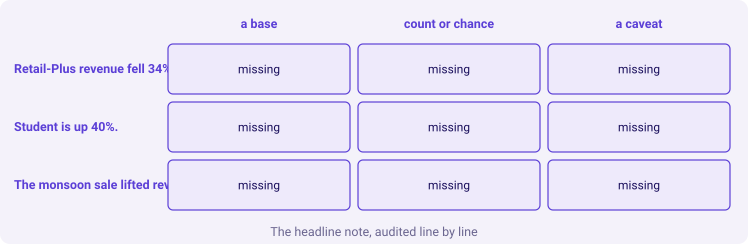

9 of 9 audit cells missing


In [6]:
def audit(line):
    """Three yes-or-no questions per line of a note: base, count or chance, caveat."""
    import re
    low = line.lower()
    base = any(w in low for w in ["of the company", "a quarter", "against rs", "per member", "than customers"])
    count = any(w in low for w in ["in 100", "chance", "count", "worlds"]) or bool(re.search(r"\b\d+ (customers|orders|members)", low))
    caveat = any(w in low for w in ["if ", "unless", "until", "not yet", "caveat", "because"])
    return ["yes" if x else "missing" for x in (base, count, caveat)]


lines = [s.strip() + "." for s in headline.split(".") if s.strip()][:3]
kit.matrix([l[:34] for l in lines], ["a base", "count or chance", "a caveat"], [audit(l) for l in lines],
           title="The headline note, audited line by line")
missing = sum(a.count("missing") for a in map(audit, lines))
print(f"{missing} of 9 audit cells missing")
kit.check("the headline note fails the audit on most cells", missing >= 7, f"{missing} missing")

## 3. The fix: the four-part note, guided on Retail-Plus

The row asks for the Retail-Plus line to be built together, in four parts, before the other two
are written alone.

**Predict before you run.** Which part does a hurried analyst leave out most often? a) the claim;
b) the evidence; c) the caveat; d) the action.

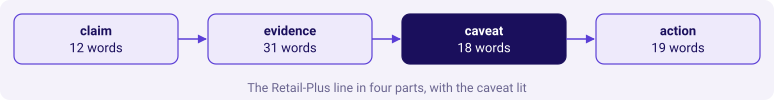

CLAIM: Retail-Plus really is spending less, and it is small against the company.
EVIDENCE: Members delivered Rs 1,110 less each, Rs 24,420 a quarter, 0.19% of the company's quarter; if nothing had changed, a fall that large turns up in about 3 in 100 shuffles.
CAVEAT: The size could be much smaller than Rs 1,110 a member, so an offer may not pay back.
ACTION: Test a Rs 11,000 offer on half the tier and hold back half, rather than funding it for all.


In [7]:
plus_line = {
    "claim": "Retail-Plus really is spending less, and it is small against the company.",
    "evidence": (f"Members delivered Rs 1,110 less each, {kit.rupees(NUMBERS['fall'])} a quarter, "
                 f"{NUMBERS['fall'] / NUMBERS['company']:.2%} of the company's quarter; if nothing had changed, "
                 f"a fall that large turns up in about {round(NUMBERS['share'] * 100)} in 100 shuffles."),
    "caveat": "The size could be much smaller than Rs 1,110 a member, so an offer may not pay back.",
    "action": (f"Test a {kit.rupees(NUMBERS['offer'])} offer on half the tier and hold back half, "
               f"rather than funding it for all."),
}
kit.flow([f"{k}\n{len(v.split())} words" for k, v in plus_line.items()], lit=2,
         title="The Retail-Plus line in four parts, with the caveat lit")
print("\n".join(f"{k.upper()}: {v}" for k, v in plus_line.items()))
kit.check("the Retail-Plus line passes the audit", audit(" ".join(plus_line.values())) == ["yes", "yes", "yes"])

**What happened.** The answer is c: the caveat is the part most often missing, and it is the part a
CEO keeps an analyst for. The Retail-Plus line now carries its base (the company's quarter), its
chance (3 in 100), its caveat (the size could be smaller) and its action with a cost.

## 4. Not yet: the Student and discount lines

"Not yet" is a claim, a caveat and an action in one sentence, provided it names what would turn it
into a yes. Write both lines and audit the whole note.

**Predict before you run.** How many words will the three answers take? a) under 50; b) about 170;
c) about 400; d) over 1,000.

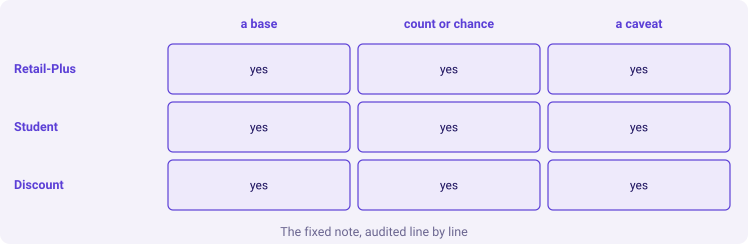

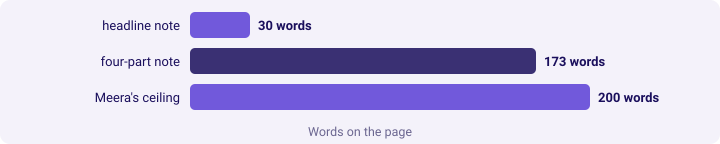

Student orders rose 40 percent on a count so small that chance alone makes that rise in about 40 in 100 worlds. Not yet: no budget moves until Student carries thirty orders a quarter.
The monsoon sale did not lift spend: inside each segment, the 30 customers who got it spent about 3% less than customers who did not, and the 6% blend is higher only because the exposed group held more Retail-Plus members. Do not repeat it as designed; if Diwali has a sale, hold back a random slice of each segment.
the whole note: 173 words


In [8]:
student_line = (f"Student orders rose {NUMBERS['student_rise']} percent on a count so small that chance alone makes "
                f"that rise in about {round(NUMBERS['student_chance'] * 100)} in 100 worlds. Not yet: no budget moves "
                f"until Student carries thirty orders a quarter.")
discount_line = (f"The monsoon sale did not lift spend: inside each segment, the {len(group('yes', 'Retail-Plus'))} customers who got it spent about "
                 f"{abs(NUMBERS['within']):.0%} less than customers who did not, and the {NUMBERS['blend']:.0%} blend "
                 f"is higher only because the exposed group held more Retail-Plus members. Do not repeat it as "
                 f"designed; if Diwali has a sale, hold back a random slice of each segment.")
note = " ".join(plus_line.values()) + " " + student_line + " " + discount_line
kit.matrix(["Retail-Plus", "Student", "Discount"], ["a base", "count or chance", "a caveat"],
           [audit(" ".join(plus_line.values())), audit(student_line), audit(discount_line)],
           title="The fixed note, audited line by line")
kit.bars([("headline note", len(headline.split())), ("four-part note", len(note.split())), ("Meera's ceiling", 200)],
         fmt=lambda v: f"{v} words", lit=[1], title="Words on the page")
print(student_line)
print(discount_line)
print(f"the whole note: {len(note.split())} words")
kit.check("the full note is under 200 words", len(note.split()) < 200, f"{len(note.split())}")
kit.check("every line of the fixed note passes the audit",
          all(a == ["yes", "yes", "yes"] for a in [audit(student_line), audit(discount_line)]))

**What happened.** The answer is b: about 170 words carry all three answers with their bases,
caveats and actions, against the headline note's 30 words and three wrong decisions. What changed:
three decisions. Retail-Plus becomes a test on half the tier, Student becomes a watch with a
threshold, and the Diwali sale becomes a redesign with a hold-back.

## A second route: every figure traced back

Read the note as a stranger would. Pull every number out of the text and trace each one to
`NUMBERS`. A figure that traces nowhere was typed by hand and is the likeliest to be wrong.

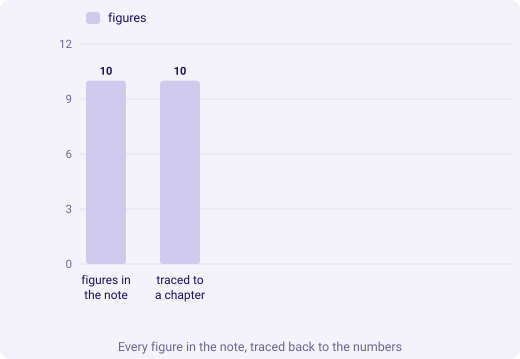

figures found: ['Rs 1,110', 'Rs 24,420', '0.19%', '3 in 100', 'Rs 1,110', 'Rs 11,000', '40 percent', '40 in 100', '3%', '6%']


In [9]:
import re

found = re.findall(r"Rs [\d,]+|\d+\.\d+%|\d+ percent|\d+ in 100|\d+%", note)
known = {kit.rupees(NUMBERS["fall"]), kit.rupees(NUMBERS["offer"]), "Rs 1,110",
         f"{NUMBERS['fall'] / NUMBERS['company']:.2%}", f"{NUMBERS['student_rise']} percent",
         f"{round(NUMBERS['share'] * 100)} in 100", f"{round(NUMBERS['student_chance'] * 100)} in 100",
         f"{abs(NUMBERS['within']):.0%}", f"{NUMBERS['blend']:.0%}"}
traced = [f for f in found if f in known]
kit.columns(["figures in the note", "traced to a chapter"], [("figures", [len(found), len(traced)])],
            width=520, title="Every figure in the note, traced back to the numbers")
print("figures found:", found)
kit.check("every figure in the note traces to a chapter's number", len(found) == len(traced) and found,
          f"{len(traced)} of {len(found)}")

**What happened.** Every figure in the note traces to a number a chapter computed, so the text and
the analysis agree. **When to switch.** Trace by hand for a one-off note; generate the note from the
numbers, as this chapter's cells did, when it repeats weekly, because a template cannot mistype.

> **Kavya's review.** "Three answers, each with its base, its caveat and a cost, and two of them say
> not yet with the thing that would change them. Marketing will push on the third on Monday; the
> next chapter is the ground you will stand on."

### In the interview

**[S] Explain a finding to a non-technical stakeholder.** "Claim first, in one sentence, with one
number and its base. Then the evidence, the caveat that would change the claim, and the action with
what it costs. If the honest answer is not yet, I say so and name what would turn it into a yes, and
by when."

**[D] The CEO wants a yes or no and the honest answer is 'not yet'; what do you say, and how do you
hold the line when marketing pushes?** "Not yet, and here is what would tell us by when. I offer the
cheapest test that settles it, such as a held-back group at Diwali. I hold the line with the split,
never with authority: I show their number reproduced, then the segments, and invite them to find
the flaw."

**[D] One-line answers, a dashboard or a written note: which do you send a CEO before a review, and
when would you switch?** "A written note under a page, each claim with its base and its caveat. I
switch to a small dashboard when the same metrics are reviewed every week, so the note only covers
what moved."

### Depth: the fact that would flip each line

A note is stronger when it says, per line, what would change it. The table is the caveat column
made explicit.

Question,Today's line,The fact that would flip it
Retail-Plus,"real, small, test the offer","a second quarter with a larger fall, or a recovery rate from a past offer"
Student,not yet,thirty orders a quarter with the rise holding
Discount,do not repeat as designed,a random hold-back at Diwali showing a lift inside segments


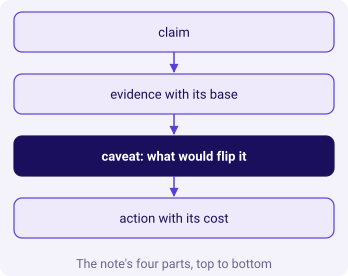

In [10]:
flips_table = [("Retail-Plus", "real, small, test the offer", "a second quarter with a larger fall, or a recovery rate from a past offer"),
               ("Student", "not yet", "thirty orders a quarter with the rise holding"),
               ("Discount", "do not repeat as designed", "a random hold-back at Diwali showing a lift inside segments")]
kit.table(["Question", "Today's line", "The fact that would flip it"], flips_table)
kit.vflow(["claim", "evidence with its base", "caveat: what would flip it", "action with its cost"], lit=2,
          title="The note's four parts, top to bottom")
kit.check("every line names the fact that would flip it", all(r[2] for r in flips_table))

In [11]:
kit.check_summary()
print("Next: chapter 6, this afternoon. Who got the discount, who did not, and what else changed?")

Next: chapter 6, this afternoon. Who got the discount, who did not, and what else changed?
